In [257]:
import pandas as pd

df = pd.read_csv("../datasets/healthcare-dataset-stroke-data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [258]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [259]:
df.drop(columns=["id"], inplace=True)

In [260]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [293]:
df[df["age"] < 10]["age"]

162     1.32
249     3.00
251     8.00
282     3.00
291     4.00
        ... 
5078    8.00
5079    1.72
5089    0.72
5095    1.08
5098    9.00
Name: age, Length: 472, dtype: float64

In [261]:
df.describe(include="object").T

,count,unique,top,freq
gender,5110,3,Female,2994
ever_married,5110,2,Yes,3353
work_type,5110,5,Private,2925
Residence_type,5110,2,Urban,2596
smoking_status,5110,4,never smoked,1892


In [262]:
num_cols = df.select_dtypes("number").columns.to_list()
cat_cols = df.select_dtypes("object").columns.to_list()

print(num_cols)
print(cat_cols)

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [263]:
unique_cat_vals = {}

for col in cat_cols:
    unique_cat_vals[col] =  df[col].unique()
    print(f"{col} : {df[col].unique()}")

gender : ['Male' 'Female' 'Other']
ever_married : ['Yes' 'No']
work_type : ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type : ['Urban' 'Rural']
smoking_status : ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [264]:
df = df[df["gender"] != "Other"]

In [265]:
print(f"Duplicated total: {df.duplicated().sum()}")

df.isna().sum()

Duplicated total: 0


gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [266]:
df = df.fillna(df["bmi"].mean())

In [267]:
def fix_float(row: float):
    to_normal = f"{row:.2f}"
    return float(to_normal)

for col in ["age", "avg_glucose_level", "bmi"]:
    df[col] = df[col].apply(fix_float)

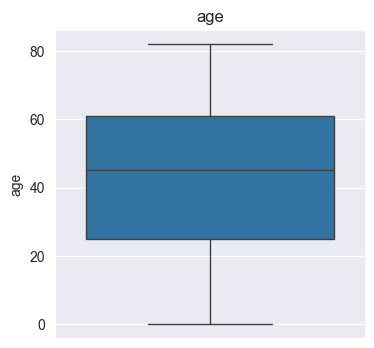

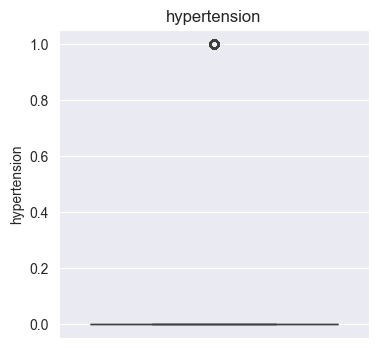

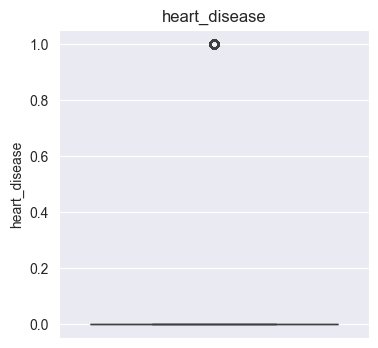

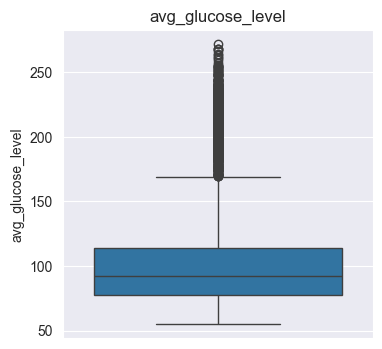

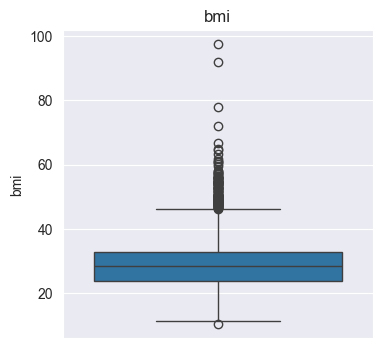

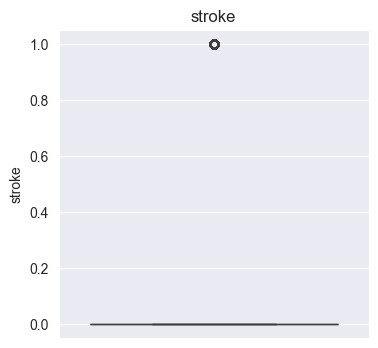

In [268]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(4, 4))
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [269]:
from sklearn.preprocessing import LabelEncoder

le_labels = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_labels[col] = le

In [270]:
le_reverse = {}

for col in cat_cols:
    unique_col = df[col].unique()
    val = le_labels[col].inverse_transform(unique_col.tolist())
    le_reverse[col] = dict(zip(val.tolist(), unique_col))

le_reverse

{'gender': {'Male': 1, 'Female': 0},
 'ever_married': {'Yes': 1, 'No': 0},
 'work_type': {'Private': 2,
  'Self-employed': 3,
  'Govt_job': 0,
  'children': 4,
  'Never_worked': 1},
 'Residence_type': {'Urban': 1, 'Rural': 0},
 'smoking_status': {'formerly smoked': 1,
  'never smoked': 2,
  'smokes': 3,
  'Unknown': 0}}

In [271]:
df["gender"].unique().tolist()

[1, 0]

In [272]:
df.tail()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,0,80.0,1,0,1,2,1,83.75,28.89,2,0
5106,0,81.0,0,0,1,3,1,125.20,40.00,2,0
5107,0,35.0,0,0,1,3,0,82.99,30.60,2,0
5108,1,51.0,0,0,1,2,0,166.29,25.60,1,0
5109,0,44.0,0,0,1,0,1,85.28,26.20,0,0


In [273]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.60,1,1
1,0,61.0,0,0,1,3,0,202.21,28.89,2,1
2,1,80.0,0,1,1,2,0,105.92,32.50,2,1
3,0,49.0,0,0,1,2,1,171.23,34.40,3,1
4,0,79.0,1,0,1,3,0,174.12,24.00,2,1


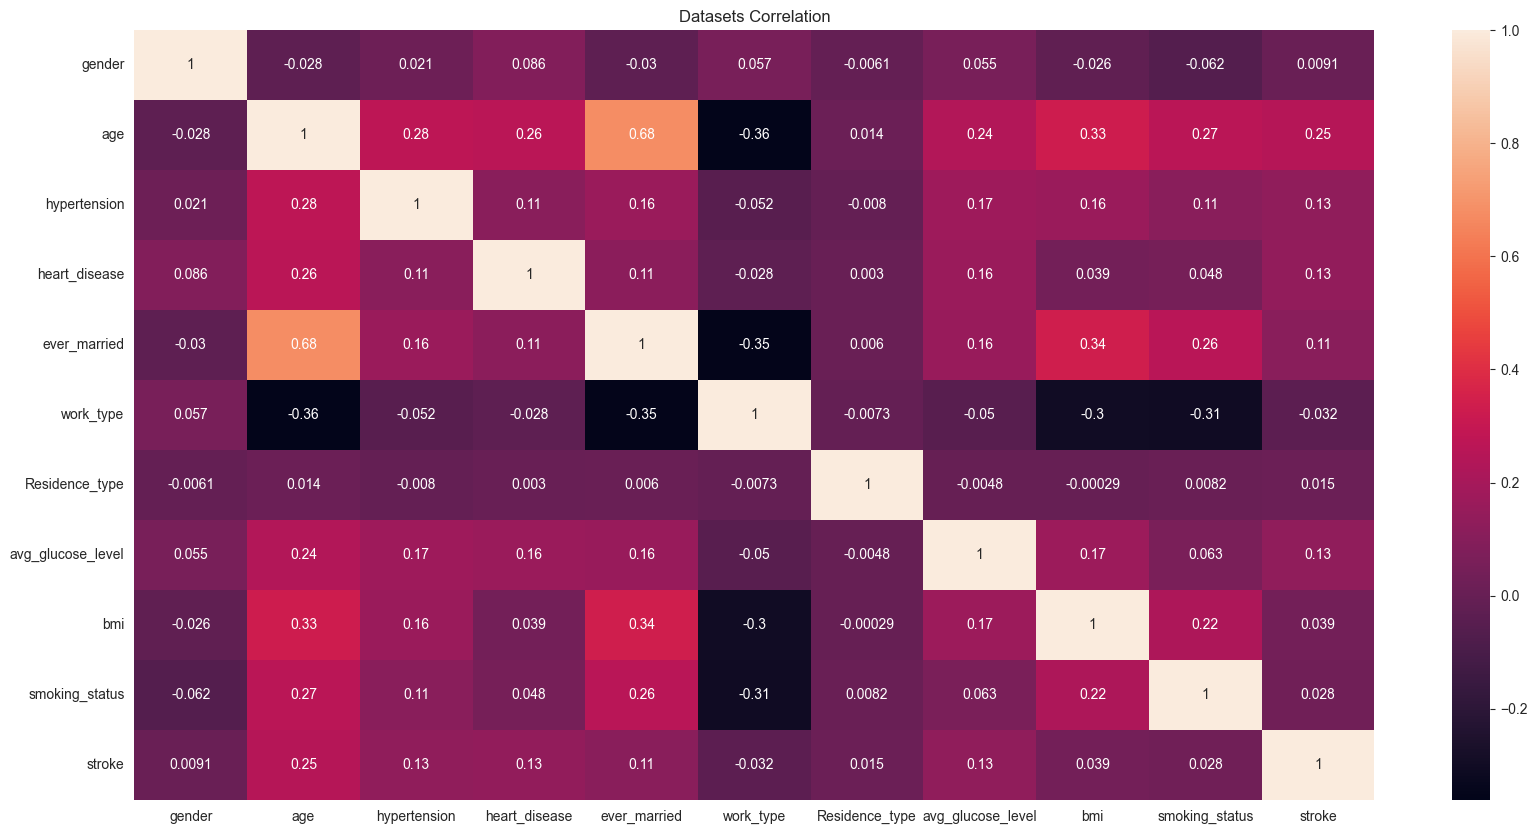

In [274]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot=True)
plt.title("Datasets Correlation")
plt.show()

The datasets is bad but i try to make all features and some features from correlation datasets

In [275]:
corr_feature = ["avg_glucose_level", "avg_glucose_level", "heart_disease", "hypertension", "age"]

In [276]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["stroke"])
y = df.stroke

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [286]:
X_train.columns.to_list()

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'avg_glucose_level',
 'bmi',
 'smoking_status']

In [277]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [278]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_score = accuracy_score(y_test, y_pred)
pre_score = precision_score(y_test, y_pred)
rec_score = recall_score(y_test, y_pred)
fone_score = f1_score(y_test, y_pred)

print(f"Accuracy Score: {acc_score}")
print(f"Precision Score: {pre_score}")
print(f"Recall Score: {rec_score}")
print(f"F1 Score: {fone_score}")

Accuracy Score: 0.9115805946791862
Precision Score: 0.23809523809523808
Recall Score: 0.1875
F1 Score: 0.2097902097902098


Try to with feature selection

In [279]:
except_X_features = ["stroke"] + [col for col in df.columns.to_list() if col not in corr_feature]

X2 = df.drop(columns=except_X_features)
y2 = df.stroke

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, random_state=42)

In [280]:
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

In [281]:
acc_score2 = accuracy_score(y_test2, y_pred2)
pre_score2 = precision_score(y_test2, y_pred2)
rec_score2 = recall_score(y_test2, y_pred2)
fone_score2 = f1_score(y_test2, y_pred2)

print(f"Accuracy Score: {acc_score2}")
print(f"Precision Score: {pre_score2}")
print(f"Recall Score: {rec_score2}")
print(f"F1 Score: {fone_score2}")

Accuracy Score: 0.9115805946791862
Precision Score: 0.18867924528301888
Recall Score: 0.125
F1 Score: 0.15037593984962405


__Conclusion__ is model with many feature is better than model less features

Try to predict

In [282]:
cols:list = df.columns.to_list()
cols.remove("stroke")
cols.insert(0, "stroke")

df_preview = df[cols]
df_preview.tail()

,stroke,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
5105,0,0,80.0,1,0,1,2,1,83.75,28.89,2
5106,0,0,81.0,0,0,1,3,1,125.20,40.00,2
5107,0,0,35.0,0,0,1,3,0,82.99,30.60,2
5108,0,1,51.0,0,0,1,2,0,166.29,25.60,1
5109,0,0,44.0,0,0,1,0,1,85.28,26.20,0


In [283]:
df_preview.loc[5108].to_list()

[0.0, 1.0, 51.0, 0.0, 0.0, 1.0, 2.0, 0.0, 166.29, 25.6, 1.0]

In [284]:
model.predict([[1.0, 51.0, 0.0, 0.0, 1.0, 2.0, 0.0, 166.29, 25.6, 1.0]])
# good predict

D:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0], dtype=int64)

__export model__

In [285]:
import pickle
import os

save_model_path = "/learn_4_lks/exam/models/classification_test.pkl"

os.makedirs(os.path.dirname(save_model_path), exist_ok=True)

with open(save_model_path, "wb") as pickle_file:
    pickle.dump(model, pickle_file)

In [287]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.60,1,1
1,0,61.0,0,0,1,3,0,202.21,28.89,2,1
2,1,80.0,0,1,1,2,0,105.92,32.50,2,1
3,0,49.0,0,0,1,2,1,171.23,34.40,3,1
4,0,79.0,1,0,1,3,0,174.12,24.00,2,1


## Kategori dan Kode

| Kategori          | Label              | Kode |
|------------------|-------------------|------|
| **Gender**       | Male              | `1`  |
|                  | Female            | `0`  |
| **Ever Married** | Yes               | `1`  |
|                  | No                | `0`  |
| **Work Type**    | Private           | `2`  |
|                  | Self-employed     | `3`  |
|                  | Govt job          | `0`  |
|                  | Children          | `4`  |
|                  | Never worked      | `1`  |
| **Residence Type** | Urban           | `1`  |
|                  | Rural             | `0`  |
| **Smoking Status** | Formerly smoked | `1`  |
|                  | Never smoked      | `2`  |
|                  | Smokes            | `3`  |
|                  | Unknown           | `0`  |
